In [1]:
import json
import pandas as pd
import h5py
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Input, Dense, Dropout, LSTM, Flatten, GRU,TimeDistributed, Conv1D, BatchNormalization
from keras.models import Model, Sequential
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
import os
import h5py
import matplotlib.pyplot as plt
from keras import regularizers
from tensorflow.keras.regularizers import l1
import ast
from tqdm import tqdm
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, truncnorm, randint
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import loguniform
from pandas import read_csv
# from keras.wrappers.scikit_learn import KerasClassifier
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import roc_auc_score
from qkeras import *
import qkeras
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt

2026-02-08 17:05:44.012023: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-08 17:05:44.060364: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-08 17:05:44.060401: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-08 17:05:44.061836: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-08 17:05:44.069343: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-08 17:05:44.070469: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [3]:
# generate test data
X_test = np.load('X_test.npy', allow_pickle=True)
y_test = np.load('y_test.npy', allow_pickle=True)

X_testzero = np.zeros((len(X_test), 100, 3))

for x in range(len(X_test)):
    for y in range(100):
        for z in range(3):
            if y >= len(X_test[x]):
                break
            X_testzero[x][y][z] = X_test[x][y][z]

# encode labels for 5 classes
num_classes = 5
y_labhot = np.zeros((len(y_test),5))

y_labhot.shape

num = 0
for x in y_test:
  if x == 0:
    y_labhot[num][0] = 1
  elif x == 1: 
    y_labhot[num][1] = 1
  elif x == 2: 
    y_labhot[num][2] = 1
  elif x == 3: 
    y_labhot[num][3] = 1
  elif x == 4: 
    y_labhot[num][4] = 1
  num = num + 1

25/25 [==============================] - 2s 76ms/step


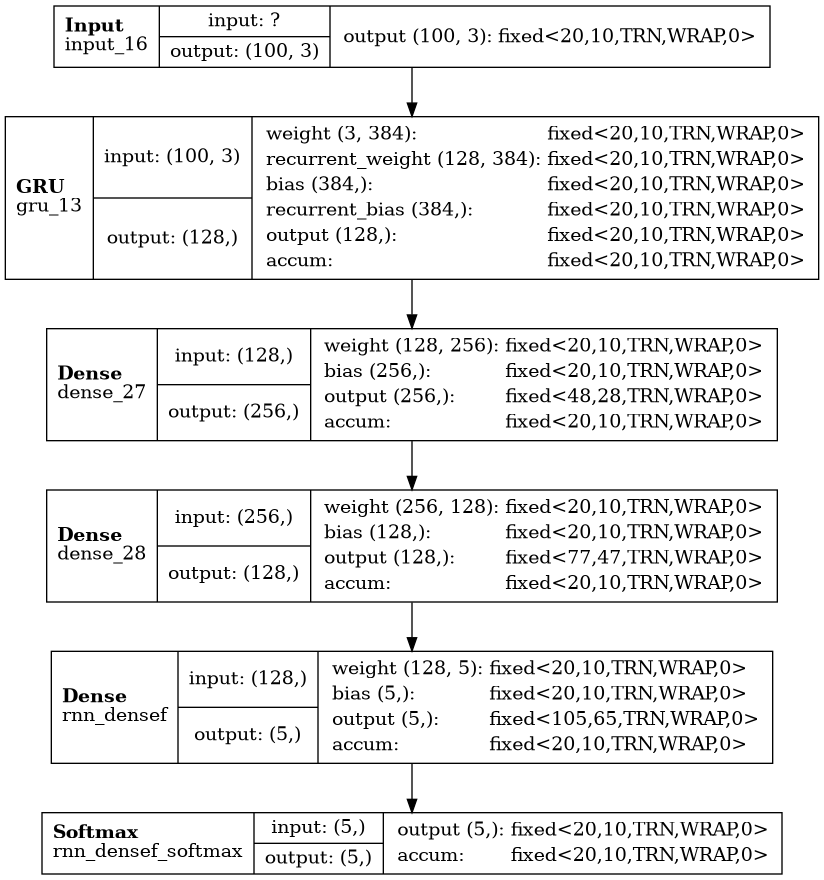

In [11]:
# create hls4ml model - JY

import hls4ml

model = load_model('./Quickdraw5Class1GRU.h5')
y_keras = model.predict(X_testzero, batch_size=512)

# fixed<x,y> where x is total number, y is integer
config = hls4ml.utils.config_from_keras_model(
    model,
    granularity='name',
    default_precision='ap_fixed<20,10>'
)

config["Model"]["Strategy"] = "Resource"

for layer in config['LayerName'].keys():
    config['LayerName']['rnn_densef_softmax']['implementation'] = 'argmax'
    # config['LayerName']['dense']['reuse_factor'] = 4096

hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    backend='Vivado',
    output_dir='model/',
    part='xc7vx690tffg1761-2',
    # part='xcu280-fsvh2892-2L-e',
    io_type='io_stream'
)

hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

In [ ]:
hls_model.compile()
X_testzero_contig = np.ascontiguousarray(X_testzero)
y_hls_name = hls_model.predict(X_testzero_contig)

In [8]:
y_pred = np.argmax(y_hls_name, axis=1)
y_true = np.argmax(y_labhot, axis=1)

print("hls4ml name  Accuracy: {}".format(accuracy_score(np.argmax(y_labhot, axis=1), np.argmax(y_hls_name, axis=1))))

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_true, y_pred, target_names=['ant', 'bee', 'butterfly', 'mosquito', 'snail']))

hls4ml name  Accuracy: 0.2
              precision    recall  f1-score   support

         ant       0.20      1.00      0.33      2500
         bee       0.00      0.00      0.00      2500
   butterfly       0.00      0.00      0.00      2500
    mosquito       0.00      0.00      0.00      2500
       snail       0.00      0.00      0.00      2500

    accuracy                           0.20     12500
   macro avg       0.04      0.20      0.07     12500
weighted avg       0.04      0.20      0.07     12500



/home/chanssen/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chanssen/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chanssen/miniconda3/envs/hls4ml-env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [ ]:
hls_model_name.build(csim=False)


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2019.1 (64-bit)
  **** SW Build 2552052 on Fri May 24 14:47:09 MDT 2019
  **** IP Build 2548770 on Fri May 24 18:01:18 MDT 2019
    ** Copyright 1986-2019 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vivado/2019.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vivado/2019.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'chanssen' on host 'hvm1' (Linux_x86_64 version 5.15.0-160-generic) on Thu Nov 13 13:14:55 PST 2025
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/chanssen/HLS4ML_VS_MANUAL/src/hdl/Quickdraw/keras/model_1/hls4ml_gru/name'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Opening project '/home/chanssen/HLS4ML_VS_MANUAL/src/hdl/Quickdraw/keras/model_1/hls4ml_gru/name/myproject_prj'.
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-10] Adding test bench file 'myp

In [2]:
import hls4ml

hls4ml.report.read_vivado_report('model_1/hls4ml_gru/name')

Found 1 solution(s) in model_1/hls4ml_gru/name/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vivado HLS Report for 'myproject'
* Date:           Thu Nov 13 14:04:03 2025

* Version:        2019.1 (Build 2552052 on Fri May 24 15:28:33 MDT 2019)
* Project:        myproject_prj
* Solution:       solution1
* Product family: virtexuplus
* Target device:  xcu280-fsvh2892-2L-e


== Performance Estimates
+ Timing (ns): 
    * Summary: 
    +--------+-------+----------+------------+
    |  Clock | Target| Estimated| Uncertainty|
    +--------+-------+----------+------------+
    |ap_clk  |   5.00|     4.346|        0.62|
    +--------+-------+----------+------------+

+ Latency (clock cycles): 
    * Summary: 
    +--------+--------+--------+--------+----------+
    |     Latency     |     Interval    | Pipeline |
    |   min  |   max  |   min  |   max  |   Type   |
    +--------+--------+--------+--------+----------+
    |  308722|  30872